In [9]:
import torch
import torch.nn as nn
from torchvision import models
import torchvision.models.segmentation as seg
import matplotlib.pyplot as plt


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CHECKPOINT_PATH = '/kaggle/input/dfl-model/pytorch/default/1/FCN_epoch_50.pth'
NUM_CLASSES = 81

print(f"Device: {device}")

Device: cuda


In [10]:
def load_model(checkpoint_path, num_classes, device):
    """Carica modello dal checkpoint"""
    model = fcn_resnet50(weights=None, num_classes=num_classes)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
        epoch = checkpoint.get('epoch', '?')
        print(f"✓ Checkpoint caricato - Epoch {epoch}")
    else:
        model.load_state_dict(checkpoint)
        print("✓ Checkpoint caricato")
    
    model.to(device)
    model.eval()
    return model

In [11]:
print("\nCaricamento modello...")
model = load_model(CHECKPOINT_PATH, NUM_CLASSES, device)


Caricamento modello...
✓ Checkpoint caricato - Epoch 50


In [16]:
target_layer_1 = model.backbone.layer1 #layer di edge, gradienti
target_layer_2 = model.backbone.layer3 #texture
target_layer_4 = model.classifier[4] #regioni semantiche

In [15]:
#funzione uncino da far apprendere al layer pe rvedere cosa apprende durante il passaggio -> no black box
def hook_fn(module, inp, out):
    global activation_output
    activation_output = out

Generazione per edges...
Generazione per textures...
Generazione per semantic...


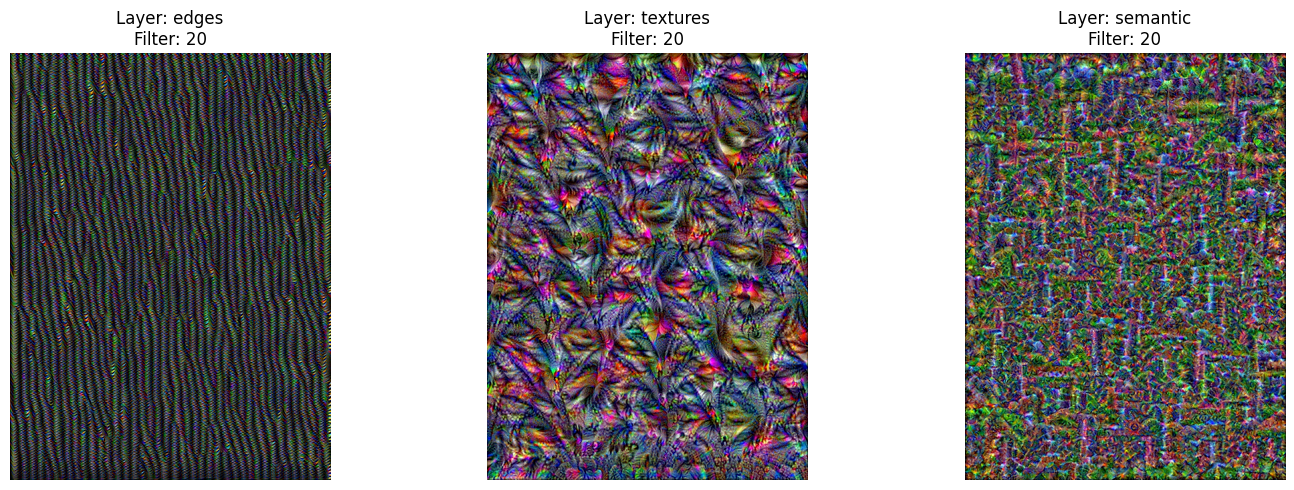

Salvataggio completato! Controlla la cartella /kaggle/working per scaricare i file.


In [25]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

layers = {
    "edges": model.backbone.layer1, #layer di edge, gradienti
    "textures": model.backbone.layer3, #texture
    "semantic": model.classifier[4] #regioni semantiche
}

activations = {}
def get_activation(name):
    def hook(model, input, output):
        activations[name] = output['out'] if isinstance(output, dict) else output
    return hook

# 3. Funzione di ottimizzazione
def generate_viz(target_layer_name, filter_index, num_steps=150):
    input_img = torch.randn(1, 3, 640, 480, device=device, requires_grad=True)
    optimizer = torch.optim.Adam([input_img], lr=0.1, weight_decay=1e-6)
    
    handle = layers[target_layer_name].register_forward_hook(get_activation(target_layer_name))
    
    for i in range(num_steps):
        optimizer.zero_grad()
        model(input_img)
        e)
        layer_output = activations[target_layer_name]
        loss = -layer_output[0, filter_index].mean()
        
        loss.backward()
        optimizer.step()
        
        if i % 5 == 0:
            with torch.no_grad():
                input_img.data = F.avg_pool2d(input_img, kernel_size=3, stride=1, padding=1)
        
        input_img.data.clamp_(0, 1)
        
    handle.remove() # Rimuovi hook
    return input_img.detach().cpu().squeeze().permute(1, 2, 0).numpy()

indices = {"edges": 20, "textures": 20, "semantic": 20} # Esempi di filtri
plt.figure(figsize=(15, 5))

for i, (name, layer) in enumerate(layers.items()):
    print(f"Generazione per {name}...")
    img = generate_viz(name, indices[name])
    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.title(f"Layer: {name}\nFilter: {indices[name]}")
    plt.axis('off')

plt.tight_layout()
plt.savefig("risultato_explainable_ai.png", dpi=300) # Questo crea il file scaricabile
plt.show()

print("Salvataggio completato! Controlla la cartella /kaggle/working per scaricare i file.")